In [4]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scipy


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [6]:
# Load the main dataset
file_path = './data/qualitative_final_v2.csv'
df = pd.read_csv(file_path)

# Drop the first two rows
df = df.iloc[2:].reset_index(drop=True)

In [7]:
# Load the issue skills file
# This file should have columns: 'issue_number', 'skill1', 'skill2', 'skill3', 'skill4'
skills_file = './data/Milestones - issues labels_final.csv'
df_skills = pd.read_csv(skills_file)

In [8]:
# Merge the main dataset with the skills dataset on 'issue_number'
df_merged = pd.merge(df, df_skills, on='issue_number', how='left')

In [9]:
# Rename Q57 for clarity and set the likert_column variable
df_merged.rename(columns={'Q57': 'Q57_answer'}, inplace=True)
likert_column = 'Q57_answer'

In [10]:
# Function to count matching skills between participant's Q57 answer and expected skills (from 4 columns)
def count_matching_skills(row, likert_column, skill_columns):
    q57_answer = row[likert_column]
    if pd.isna(q57_answer):
        return 0
    
    # Replace specified phrases before processing
    q57_answer = q57_answer.replace("Network Development", "Network")
    q57_answer = q57_answer.replace("User Interface (UI)", "User Interface")
    
    # Split the Q57 answer into individual skills and convert to lowercase
    q57_list = [item.strip().lower() for item in q57_answer.split(",")]
    
    # Build a set of expected skills from the four skill columns, ignoring NaN values
    expected_skills = set()
    for col in skill_columns:
        skill = row[col]
        if pd.notna(skill):
            expected_skills.add(skill.strip().lower())
    
    # Count the number of matching skills
    matches = set(q57_list).intersection(expected_skills)
    return len(matches)

# Define the skill columns
skill_columns = ['skill1', 'skill2', 'skill3', 'skill4']

# Compute the matching count for each participant
df_merged['matching_count'] = df_merged.apply(lambda row: count_matching_skills(row, likert_column, skill_columns), axis=1)

# Display a sample of the data
df_merged[['issue_number', 'Q57_answer', 'skill1', 'skill2', 'skill3', 'skill4', 'matching_count']].head()

,issue_number,Q57_answer,skill1,skill2,skill3,skill4,matching_count
0,5679.0,NaN,Input and Output,Test,NaN,NaN,0
1,5485.0,NaN,Input and Output,NaN,NaN,NaN,0
2,4612.0,NaN,User Interface,NaN,NaN,NaN,0
3,5194.0,NaN,Google common,Network,Logging,Input and Output,0
4,4612.0,"User Interface (UI),Testing",User Interface,NaN,NaN,NaN,1


In [22]:
df_merged

,P,DistributionChannel,group,Q57_answer,correct,sound solution,issue_number,label1,label2,label3,label4,label5,label6,skill1,skill2,skill3,skill4,matching_count
0,P0,anonymous,Control,NaN,0.0,0.0,5679.0,API: Test,API: Input and Output,NaN,NaN,NaN,NaN,Input and Output,Test,NaN,NaN,0
1,P1,anonymous,Treatment,NaN,1.0,1.0,5485.0,fetcher,API: Input and Output,NaN,NaN,NaN,NaN,Input and Output,NaN,NaN,NaN,0
2,P2,anonymous,Control,NaN,0.0,0.0,4612.0,entry editor,type: bug,peferences,API: User Interface,NaN,NaN,User Interface,NaN,NaN,NaN,0
3,P3,anonymous,Treatment,NaN,0.0,1.0,5194.0,type: bug,API: Google common,API: Network,API: Logging,API: Input and Output,NaN,Google common,Network,Logging,Input and Output,0
4,P4,anonymous,Control,"User Interface (UI),Testing",0.0,0.0,4612.0,entry editor,type: bug,peferences,API: User Interface,NaN,NaN,User Interface,NaN,NaN,NaN,1
5,P5,anonymous,Treatment,"User Interface (UI),Testing,Network Developmen...",0.0,1.0,5069.0,entre-preview,search,type: bug,API: Network,API: User Interface,API: Logging,Network,User Interface,Logging,NaN,2
6,P6,anonymous,Control,"Testing,Google Common",0.0,0.0,5485.0,fetcher,API: Input and Output,NaN,NaN,NaN,NaN,Input and Output,NaN,NaN,NaN,0
7,P7,anonymous,Treatment,"Logging,Testing,Input and Output",0.0,0.0,5485.0,fetcher,API: Input and Output,NaN,NaN,NaN,NaN,Input and Output,NaN,NaN,NaN,1
8,P8,anonymous,Treatment,"User Interface (UI),Logging,Testing,Input and ...",1.0,1.0,5485.0,fetcher,API: Input and Output,NaN,NaN,NaN,NaN,Input and Output,NaN,NaN,NaN,1
9,P9,anonymous,Control,"User Interface (UI),Testing",0.0,1.0,5069.0,entre-preview,search,type: bug,API: Network,API: User Interface,API: Logging,Network,User Interface,Logging,NaN,1


In [ ]:
from scipy.stats import brunnermunzel

# Brunner–Munzel test (handles ties and unequal variances)
bm_stat, bm_p = brunnermunzel(control, treatment, alternative='two-sided')
print('Brunner–Munzel test: W =', bm_stat, ', p-value =', bm_p)

def vargha_delaney_A(x, y):
    """Stochastic superiority: P(x > y) + 0.5 P(x = y). Â = 0.5 means no effect."""
    n1, n2 = len(x), len(y)
    greater = sum(1 for xi in x for yj in y if xi > yj)
    equal = sum(1 for xi in x for yj in y if xi == yj)
    return (greater + 0.5 * equal) / (n1 * n2)

def vargha_delaney_magnitude(a):
    """Vargha & Delaney (2000) magnitude, using distance from 0.5."""
    d = max(a, 1 - a)
    if d < 0.56:
        return 'negligible'
    if d < 0.64:
        return 'small'
    if d < 0.71:
        return 'medium'
    return 'large'

A_control = vargha_delaney_A(list(control), list(treatment))
A_treatment = 1.0 - A_control  # P(Treatment > Control) + 0.5 P(tie)
print("Vargha–Delaney Â (Control > Treatment):", A_control)
print("Vargha–Delaney Â (Treatment > Control):", A_treatment)
print("Magnitude:", vargha_delaney_magnitude(A_treatment))


In [11]:
# Extract matching_count values for the two groups
control = df_merged[df_merged['group'] == 'Control']['matching_count'].dropna()
treatment = df_merged[df_merged['group'] == 'Treatment']['matching_count'].dropna()



In [12]:
control

0     0
2     0
4     1
6     0
9     1
10    1
13    1
14    0
17    1
18    0
20    1
22    0
23    0
Name: matching_count, dtype: int64

In [13]:
treatment

1     0
3     0
5     2
7     1
8     1
11    2
12    1
15    1
16    2
19    1
21    1
24    0
25    3
Name: matching_count, dtype: int64

In [14]:
# Perform the Mann-Whitney U test
u_stat, p_value = mannwhitneyu(control, treatment, alternative='two-sided')
print('Mann-Whitney U Test: U statistic =', u_stat, ', p-value =', p_value)

# Function to compute Cliff's Delta
def cliffs_delta(x, y):
    n1, n2 = len(x), len(y)
    greater = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    delta = (greater - less) / (n1 * n2)
    return delta

# Compute Cliff's Delta
delta_value = cliffs_delta(list(control), list(treatment))
print("Cliff's Delta:", delta_value)

Mann-Whitney U Test: U statistic = 46.5 , p-value = 0.036374161095233365
Cliff's Delta: -0.44970414201183434


In [15]:
pd.set_option('display.max_columns', None)
df_merged[['issue_number', 'Q57_answer', 'skill1', 'skill2', 'skill3', 'skill4', 'matching_count']]

,issue_number,Q57_answer,skill1,skill2,skill3,skill4,matching_count
0,5679.0,NaN,Input and Output,Test,NaN,NaN,0
1,5485.0,NaN,Input and Output,NaN,NaN,NaN,0
2,4612.0,NaN,User Interface,NaN,NaN,NaN,0
3,5194.0,NaN,Google common,Network,Logging,Input and Output,0
4,4612.0,"User Interface (UI),Testing",User Interface,NaN,NaN,NaN,1
5,5069.0,"User Interface (UI),Testing,Network Developmen...",Network,User Interface,Logging,NaN,2
6,5485.0,"Testing,Google Common",Input and Output,NaN,NaN,NaN,0
7,5485.0,"Logging,Testing,Input and Output",Input and Output,NaN,NaN,NaN,1
8,5485.0,"User Interface (UI),Logging,Testing,Input and ...",Input and Output,NaN,NaN,NaN,1
9,5069.0,"User Interface (UI),Testing",Network,User Interface,Logging,NaN,1


In [16]:
df_merged.columns

Index(['P', 'DistributionChannel', 'group', 'Q57_answer', 'correct',
       'sound solution', 'issue_number', 'label1', 'label2', 'label3',
       'label4', 'label5', 'label6', 'skill1', 'skill2', 'skill3', 'skill4',
       'matching_count'],
      dtype='str')

/var/folders/wl/6xnv040j13jcrpzs4662mdwr0000gn/T/ipykernel_11574/3178096265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='matching_count', y='group', data=df_merged, orient='h',palette=colors)


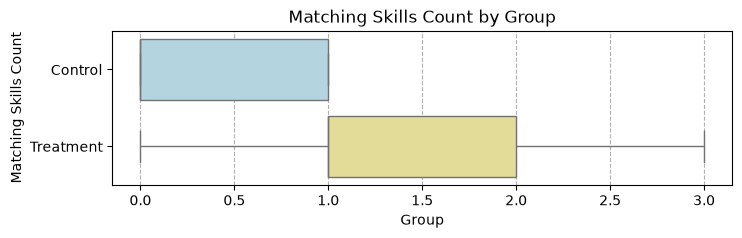

In [17]:
# Melt the DataFrame to long format
df_melted = pd.melt(df, var_name='Categories', value_name='Values')

# Create horizontal box plot
colors=['lightblue','khaki']
plt.figure(figsize=(8, 2))
sns.boxplot(x='matching_count', y='group', data=df_merged, orient='h',palette=colors)
plt.grid(axis='x', linestyle='--')
plt.title('Matching Skills Count by Group')
plt.xlabel('Group')
plt.ylabel('Matching Skills Count')
plt.savefig('./figures/skill-box-plot2.pdf', format='pdf')
plt.savefig('./figures/skill-box-plot2.png', format='png')

plt.show()

In [18]:
control.describe()

count    13.000000
mean      0.461538
std       0.518875
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: matching_count, dtype: float64

In [19]:
control.median

<bound method Series.median of 0     0
2     0
4     1
6     0
9     1
10    1
13    1
14    0
17    1
18    0
20    1
22    0
23    0
Name: matching_count, dtype: int64>

In [20]:
treatment.describe()

count    13.000000
mean      1.153846
std       0.898717
min       0.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       3.000000
Name: matching_count, dtype: float64

In [21]:
treatment.median

<bound method Series.median of 1     0
3     0
5     2
7     1
8     1
11    2
12    1
15    1
16    2
19    1
21    1
24    0
25    3
Name: matching_count, dtype: int64>